   Match_ID  Season  Match_Date       City                   Venue  \
0         1    2017  2017-05-11  Bengaluru  M. Chinnaswamy Stadium   
1         1    2017  2017-05-11  Bengaluru  M. Chinnaswamy Stadium   
2         1    2017  2017-05-11  Bengaluru  M. Chinnaswamy Stadium   
3         1    2017  2017-05-11  Bengaluru  M. Chinnaswamy Stadium   
4         1    2017  2017-05-11  Bengaluru  M. Chinnaswamy Stadium   

            Team1           Team2     Toss_Winner Toss_Decision  \
0  Gujarat Titans  Mumbai Indians  Gujarat Titans         field   
1  Gujarat Titans  Mumbai Indians  Gujarat Titans         field   
2  Gujarat Titans  Mumbai Indians  Gujarat Titans         field   
3  Gujarat Titans  Mumbai Indians  Gujarat Titans         field   
4  Gujarat Titans  Mumbai Indians  Gujarat Titans         field   

           Winner  ...    Batting_Team    Bowling_Team        Batsman  \
0  Mumbai Indians  ...  Gujarat Titans  Mumbai Indians  Sai Sudharsan   
1  Mumbai Indians  ...  Gujara

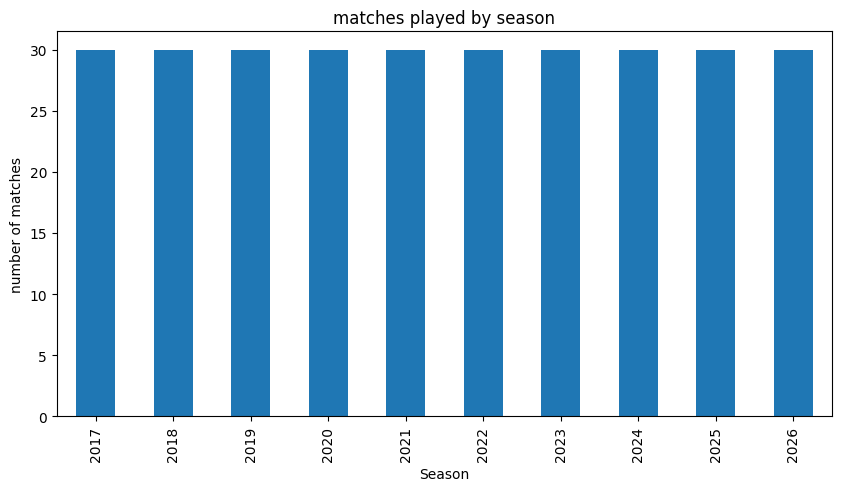

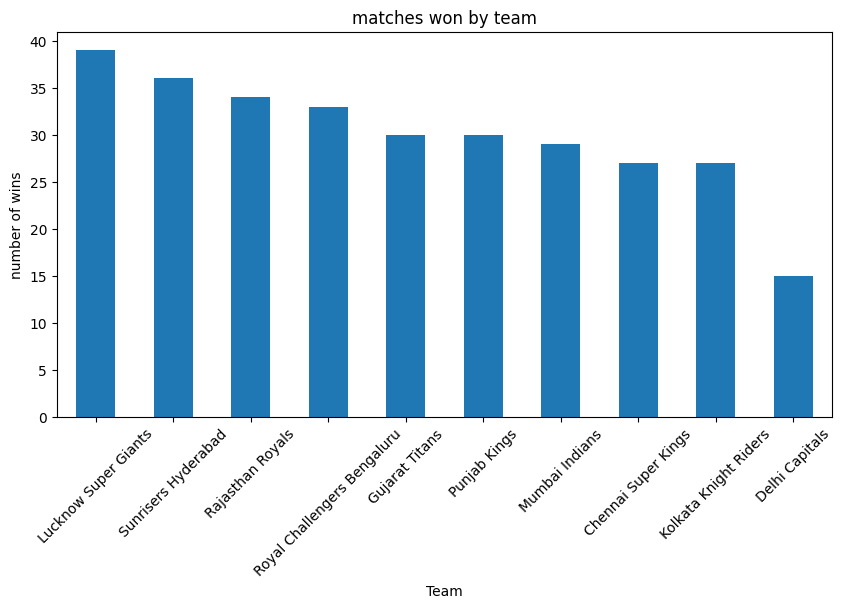

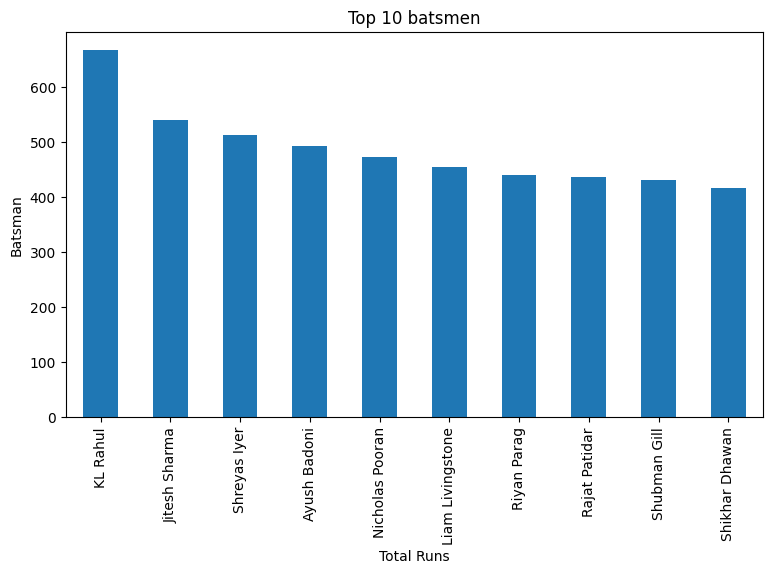

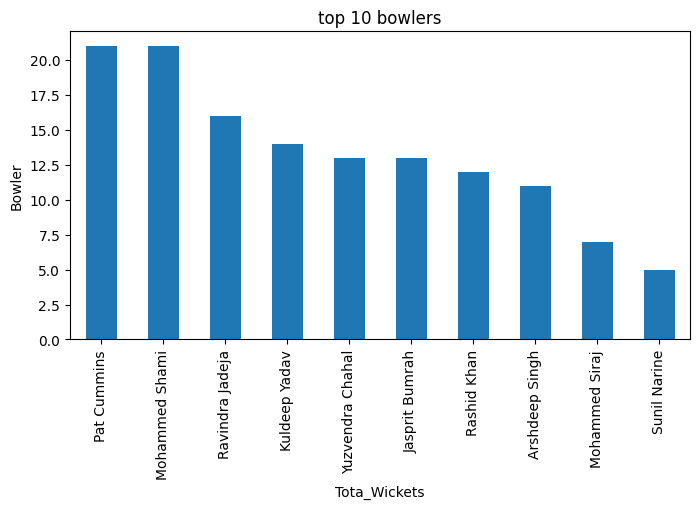

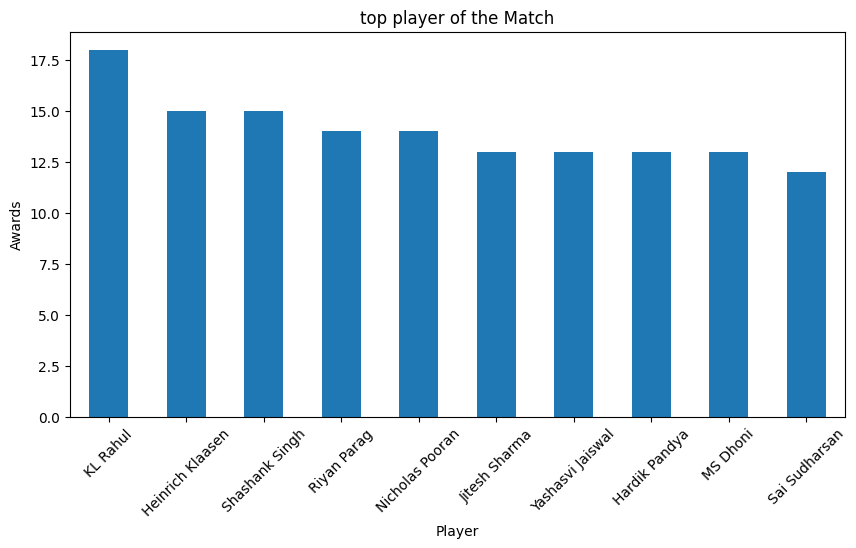

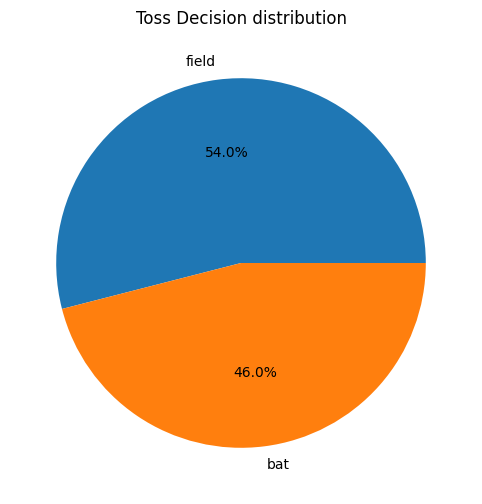

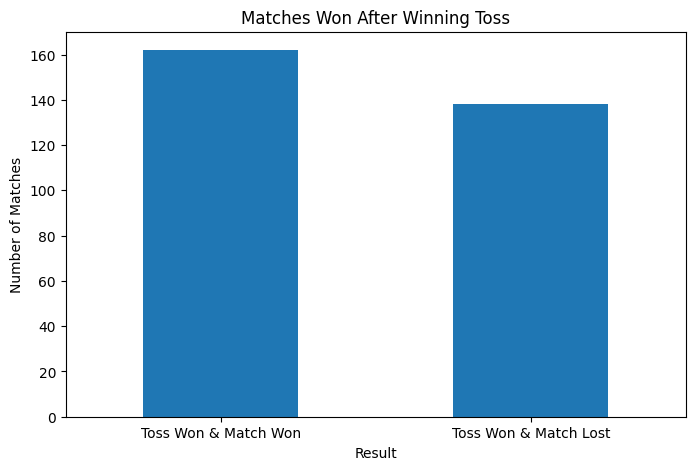

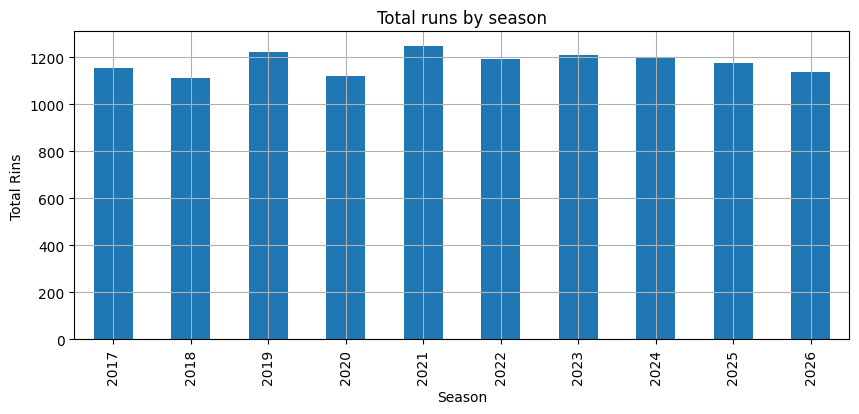

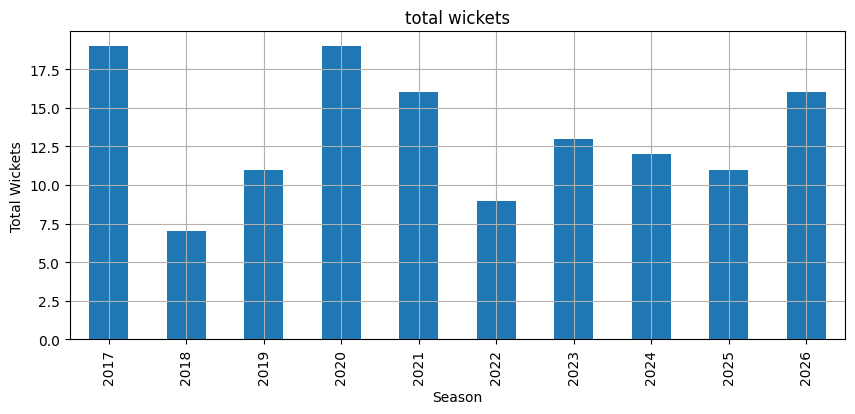

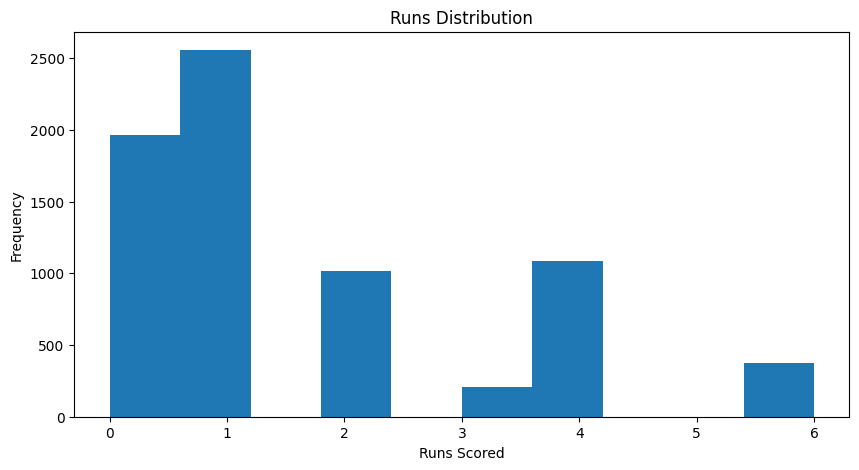

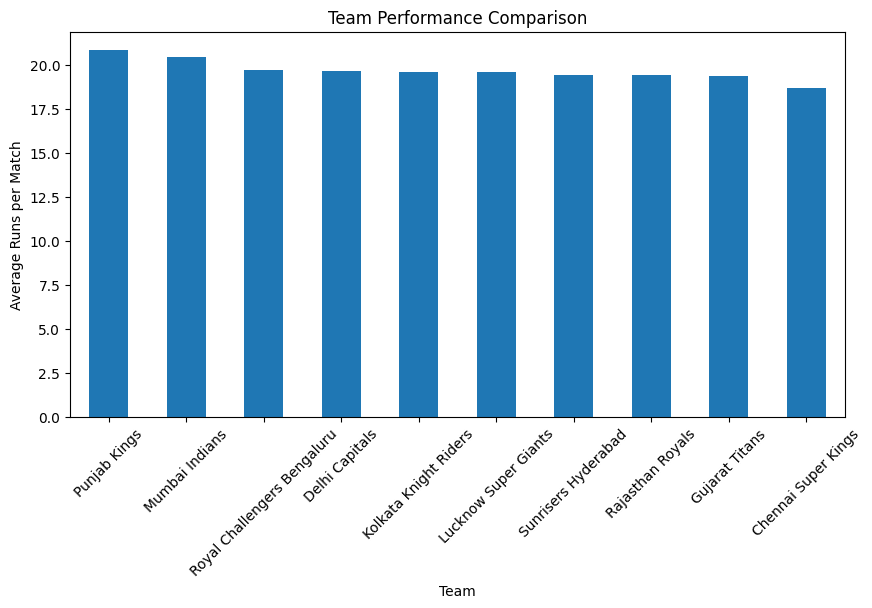

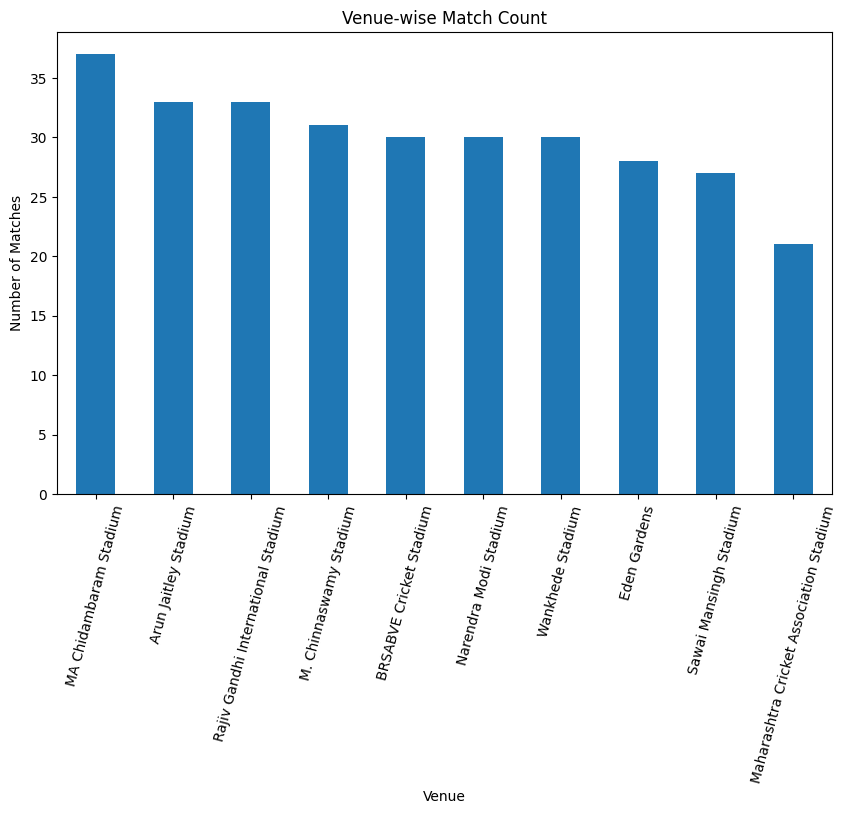

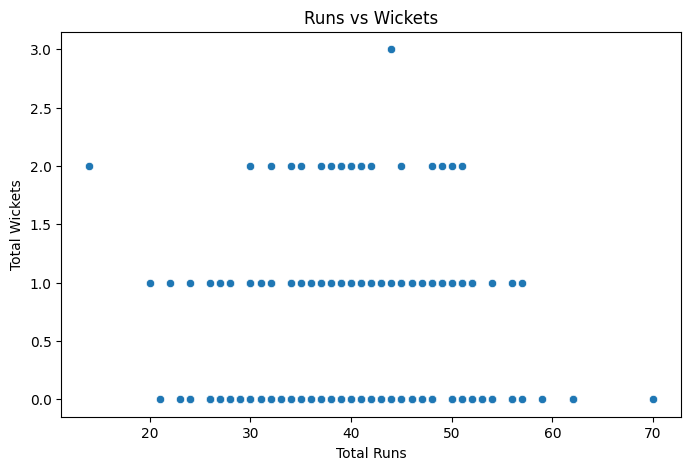

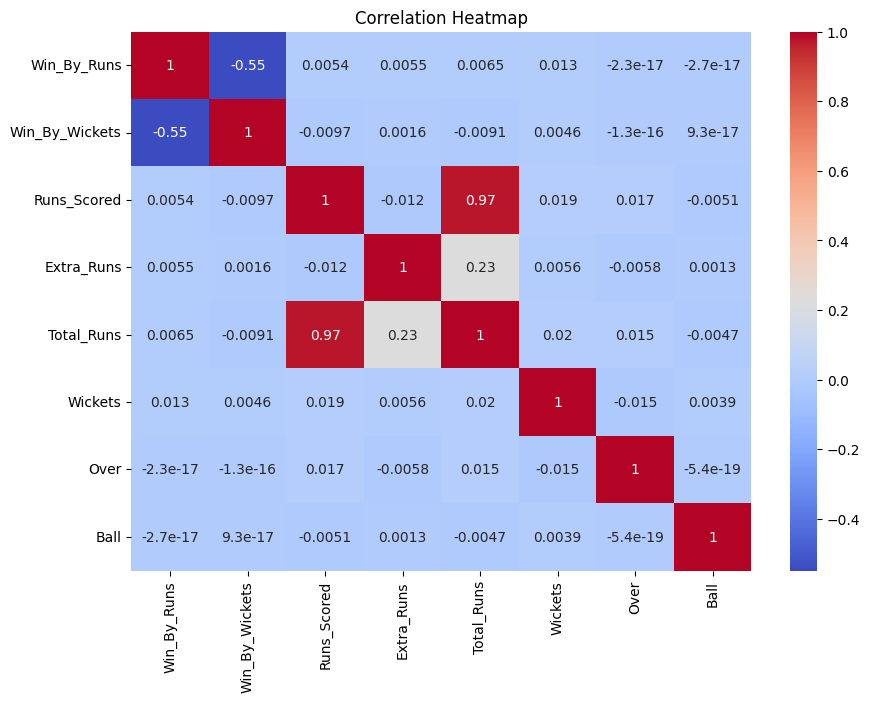

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#data loading
df=pd.read_csv("IPL_Data_Analysis_Same_Format.csv")
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
print(df.select_dtypes(include=np.number).columns)
print(df.select_dtypes(include="object").columns)
#data exploration & cleaning
print(df.dtypes)
print(df.info)
print(df.describe(include="all"))
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.drop_duplicates())
print(df["Team1"].unique())
print(df["Team2"].unique())
print(df["Winner"].unique())
print(df["Toss_Decision"].unique())
print(df["City"].unique())
print(df["Season"].unique())
print(df["Result"].unique())
all_teams=pd.concat([df["Team1"],df["Team2"],df["Winner"]])
print(sorted(all_teams.dropna().unique()))
print(df.isnull().sum())
print(df.dropna())
df["Match_Date"]=pd.to_datetime(df["Match_Date"])
print(df["Match_Date"].dtype)
print(df.shape)
print(df.isnull().sum().sum())
print(df.duplicated().sum())
print(df.head())
#DATA ANALYSIS USING NUMPY AND PANDAS
#18.total number of matches
total_matches=df["Match_ID"].nunique()
print(total_matches)
#19
matches_per_season=df.groupby("Season")["Match_ID"].nunique()
print(matches_per_season)
#20
team_wins=df.groupby("Winner")["Match_ID"].nunique().sort_values(ascending=False)
print(team_wins)
#21
print(team_wins.idxmax(),"-",team_wins.max())
#22
print(team_wins.idxmin(),"-",team_wins.min())
#23
player_awards=df.groupby("Player_of_Match")["Match_ID"].nunique()
print(player_awards.idxmax(),"-",player_awards.max())
#24
venue_matches=df.groupby("Venue")["Match_ID"].nunique()
print(venue_matches.idxmax(),"-",venue_matches.max())
#25
print(df["Toss_Decision"].value_counts())
#27
print(df["Win_By_Runs"].max())
#28
print(df["Win_By_Wickets"].max())
#29
player_runs=df.groupby("Batsman")["Runs_Scored"].sum()
print(player_runs.idxmax(),"-",player_runs.max(),"runs")
#30
bowler_wickets=df.groupby("Bowler")["Wickets"].sum()
print(bowler_wickets.idxmax(),"-",bowler_wickets.max(),"Wickets")
#31
print(player_runs.sort_values(ascending=False).head(10))
#32
print(bowler_wickets.sort_values(ascending=False).head(10))
#33
season_runs=df.groupby("Season")["Runs_Scored"].sum()
print(season_runs)
#34
season_wickets=df.groupby("Season")["Wickets"].sum()
print(season_wickets)
#35
match_runs=df.groupby("Match_ID")["Runs_Scored"].sum()
print(round(np.mean(match_runs),2))
#36
print(df.groupby("Batting_Team")["Runs_Scored"].mean())
#37
print(df.drop_duplicates("Match_ID").groupby(["Season","Winner"])["Match_ID"].count())
#38
print(df.drop_duplicates("Match_ID").groupby(["Winner","Venue"])["Match_ID"].count().groupby(level=0).idxmax())
#39
print((df.drop_duplicates("Match_ID")["Toss_Winner"]==df.drop_duplicates("Match_ID")["Winner"]).value_counts())

#40
print(df.groupby("Season")["Runs_Scored"].sum().sort_values(ascending=False).head())
#PART 4:PYTHON DATA VISUALIZATION
#create the follwing visualizaions using matplotlib and seaborn
#1
matches_season=df.groupby("Season")["Match_ID"].nunique()
plt.figure(figsize=(10,5))
matches_season.plot(kind="bar")
plt.title("matches played by season")
plt.xlabel("Season")
plt.ylabel("number of matches")
plt.show()
#2
team_wins=df.groupby("Winner")["Match_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(10,5))
team_wins.plot(kind="bar")
plt.title("matches won by team")
plt.xlabel("Team")
plt.ylabel("number of wins")
plt.xticks(rotation=45)
plt.show()
#3
top_batsmen=df.groupby("Batsman")["Runs_Scored"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,5))
top_batsmen.plot(kind="bar")
plt.title("Top 10 batsmen")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.show()
#4
top_bowlers=df.groupby("Bowler")["Wickets"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
top_bowlers.plot(kind="bar")
plt.title("top 10 bowlers")
plt.xlabel("Tota_Wickets")
plt.ylabel("Bowler")
plt.show()
#5
pom=df.groupby("Player_of_Match")["Match_ID"].nunique().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
pom.plot(kind="bar")
plt.title("top player of the Match")
plt.xlabel("Player")
plt.ylabel("Awards")
plt.xticks(rotation=45)
plt.show()
#6
toss=df["Toss_Decision"].value_counts()
plt.figure(figsize=(9,6))
plt.pie(toss,labels=toss.index,autopct="%1.1f%%")
plt.title("Toss Decision distribution")
plt.show()
#7
matches=df.drop_duplicates("Match_ID")
toss_result = matches["Toss_Winner"].eq(matches["Winner"])
toss_result = toss_result.map({
    True: "Toss Won & Match Won",
    False: "Toss Won & Match Lost"
})
toss_result = toss_result.value_counts()
plt.figure(figsize=(8,5))
toss_result.plot(kind="bar")
plt.title("Matches Won After Winning Toss")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.show()
#8
season_runs=df.groupby("Season")["Runs_Scored"].sum()
plt.figure(figsize=(10,4))
season_runs.plot(kind="bar")
plt.title("Total runs by season")
plt.xlabel("Season")
plt.ylabel("Total Rins")
plt.grid()
plt.show()
#9
season_wickets=df.groupby("Season")["Wickets"].sum()
plt.figure(figsize=(10,4))
season_wickets.plot(kind="bar")
plt.title("total wickets")
plt.xlabel("Season")
plt.ylabel("Total Wickets")
plt.grid()
plt.show()
#10
plt.figure(figsize=(10,5))
plt.hist(df["Runs_Scored"], bins=10)
plt.title("Runs Distribution")
plt.xlabel("Runs Scored")
plt.ylabel("Frequency")
plt.show()

#11
#11
team_runs = df.groupby(
    ["Match_ID", "Batting_Team"]
)["Runs_Scored"].sum()

team_average = team_runs.groupby(
    level=1
).mean()

team_average = team_average.sort_values(
    ascending=False
)
plt.figure(figsize=(10,5))
team_average.plot(kind="bar")
plt.title("Team Performance Comparison")
plt.xlabel("Team")
plt.ylabel("Average Runs per Match")
plt.xticks(rotation=45)
plt.show()
#12
venue_matches = df.groupby("Venue")["Match_ID"].nunique()

venue_matches = venue_matches.sort_values(
    ascending=False
)
plt.figure(figsize=(10,6))
venue_matches.plot(kind="bar")
plt.title("Venue-wise Match Count")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")
plt.xticks(rotation=75)
plt.show()

#13
match_stats = df.groupby("Match_ID")[
    ["Runs_Scored", "Wickets"]
].sum()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=match_stats["Runs_Scored"],
    y=match_stats["Wickets"]
)

plt.title("Runs vs Wickets")
plt.xlabel("Total Runs")
plt.ylabel("Total Wickets")
plt.show()
#14
correlation = df[
    [
        "Win_By_Runs",
        "Win_By_Wickets",
        "Runs_Scored",
        "Extra_Runs",
        "Total_Runs",
        "Wickets",
        "Over",
        "Ball"
    ]
].corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
